In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_sROM, optimize_sROMs_naive, target_function, get_predictions
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw
from smooth_POD_ROM.plots_paper import Fig3
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

8.030570172000001


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


WIP: compare sROM vs sROMs (rule of thumb) vs sROMs (average)

In [3]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 50,
    "n_test": 25,  # 25
    "g": small_saw_tooth, #small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 100,
    "monitor_convergence": False,
    "sROM_only": False,
    "sROM_only": "calc_based_on_distance",
}

In [ ]:
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
e_rom = np.zeros(len(NN),)
e_srom = np.zeros(len(NN),)
e_sroms1 = np.zeros(len(NN),)
e_sroms2 = np.zeros(len(NN),)
sS_srom = np.zeros(len(NN),)
sS_sroms1 = np.zeros(len(NN),)
sD_sroms1 = np.zeros(len(NN),)
sS_sroms2 = np.zeros(len(NN),)
c_sroms2 = np.zeros(len(NN),)

for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    case["rank"] = rank
    case["n_train"] = n_train
    
    case["sigmaD"] = "calc_based_on_distance"
    case["sROM_only"] = True
    case["n_test"] = 25
    parameters = optimize_sROM(case)
    case["n_test"] = 100
    case["sigma"] = parameters[0]
    mean_ROM, mean_sROM, mean_sROMs = target_function(case)
    e_rom[i] = mean_ROM
    e_srom[i] = mean_sROM
    sS_srom[i] = parameters[0]
    print("\n\n")

    case["sROM_only"] = False
    case["n_test"] = 25
    parameters = optimize_sROMs_naive(case)
    case["sigmaD"] = np.zeros((100,))
    case["n_test"] = 100
    case["sigma"], case["sigmaD"][:] = parameters[0], parameters[1]
    mean_ROM, mean_sROM, mean_sROMs = target_function(case)
    e_sroms1[i] = mean_sROMs
    sS_sroms1[i] = parameters[0]
    sD_sroms1[i] = parameters[1]
    print("\n\n")

    case["sROM_only"] = False
    case["sigmaD"] = "calc_based_on_distance"
    case["n_test"] = 25
    parameters = optimize_hyperparameters(case)
    case["n_test"] = 100
    case["sigma"], case["c"] = parameters[0], parameters[1]
    mean_ROM, mean_sROM, mean_sROMs = target_function(case)
    e_sroms2[i] = mean_sROMs
    sS_sroms2[i] = parameters[0]
    c_sroms2[i] = parameters[1]
    print("\n\n")

3
max: 0.06666666666666667
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.03333833, -, 0.10422076, 0.08557249, -, -17.8930
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.05555722, -, 0.10422076, 0.08434334, -, -19.0724
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.01111944, -, 0.10422076, 0.09148062, -, -12.2242
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.06296352, -, 0.10422076, 0.08415670, -, -19.2515
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.04815093, -, 0.10422076, 0.08460897, -, -18.8175
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.04074463, -, 0.10422076, 0.08499386, -, -18.4482
num_iter, n_train, n_test, sigma_S, sigma_D

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.16716667, 0.16716667, 0.10422076, 0.08407622, 0.08323444, -20.1364
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.27794444, 0.16716667, 0.10422076, 0.08462061, 0.08435829, -19.0581
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.05638889, 0.16716667, 0.10422076, 0.08431898, 0.07718556, -25.9403
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.16716667, 0.27794444, 0.10422076, 0.08407622, 0.07902179, -24.1785
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.16716667, 0.05638889, 0.10422076, 0.08407622, 0.08402443, -19.3784
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 25, 0.05638889, 0.27794444, 0.10422

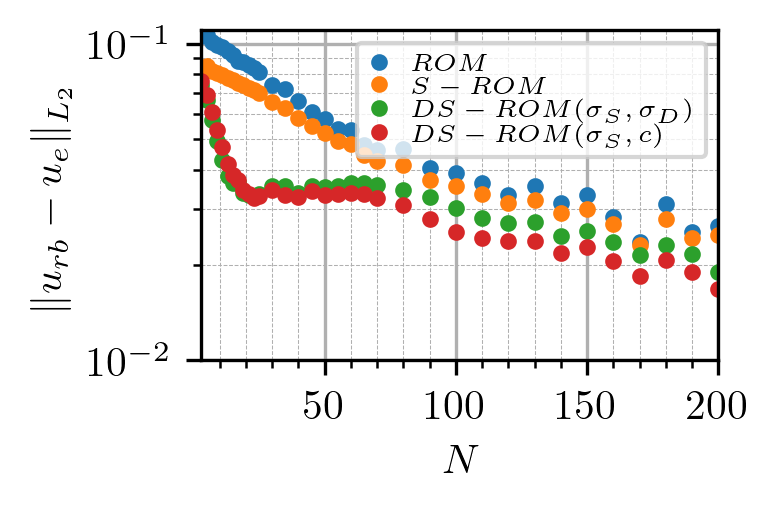

In [7]:
#NN = [10, 20, 30, 50, 75, 100, 125, 150, 175, 200]
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))


plt.plot(NN, e_rom, "C0o", ms=3, label=r"$ROM$")
plt.plot(NN, e_srom, "C1o", ms=3, label=r"$S-ROM$")
plt.plot(NN, e_sroms1, "C2o", ms=3, label=r"$DS-ROM (\sigma_S, \sigma_D)$")
plt.plot(NN, e_sroms2, "C3o", ms=3, label=r"$DS-ROM (\sigma_S, c)$")





#plt.plot(NN, dN_ROM, "k.-", ms=2, label="no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
#plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")# r"$u_{\mu,Srb}$"

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 200, 21, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
#ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 200)
plt.ylim(1e-2, 0.11)
plt.show()

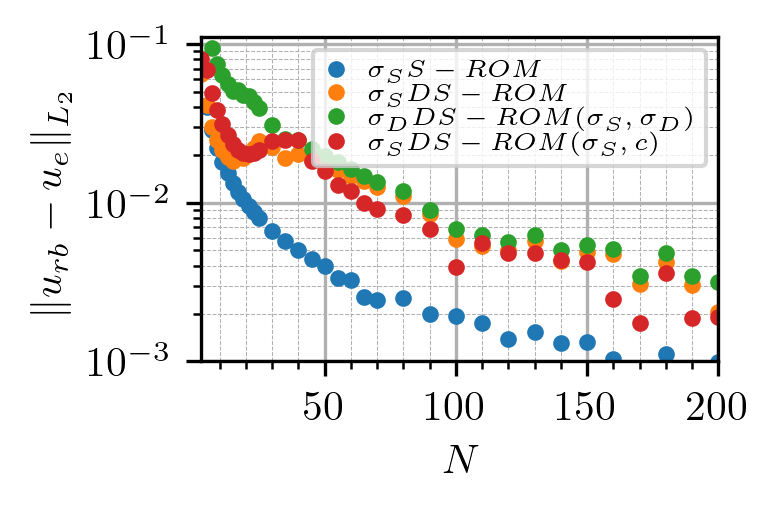

In [12]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))

plt.plot(NN, sS_srom, "C0o", ms=3, label=r"$\sigma_S S-ROM$")
plt.plot(NN, sS_sroms1, "C1o", ms=3, label=r"$\sigma_S DS-ROM$")
plt.plot(NN, sD_sroms1, "C2o", ms=3, label=r"$\sigma_D DS-ROM (\sigma_S, \sigma_D)$")
plt.plot(NN, sS_sroms2, "C3o", ms=3, label=r"$\sigma_S DS-ROM (\sigma_S, c)$")

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 200, 21, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
#ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 200)
plt.ylim(1e-3, 0.11)
plt.show()

In [ ]:

np.save("./10_NN.npy", NN)

np.save("./10_sS_srom.npy", sS_srom)
np.save("./10_sS_sroms1.npy", sS_sroms1)
np.save("./10_sD_sroms1.npy", sD_sroms1)
np.save("./10_sS_sroms2.npy", sS_sroms2)
np.save("./10_c_sroms2.npy", c_sroms2)

np.save("./10_e_rom.npy", e_rom)
np.save("./10_e_srom.npy", e_srom)
np.save("./10_e_sroms1.npy", e_sroms1)
np.save("./10_e_sroms2.npy", e_sroms2)
